# Calculate top/bottom 10 subjects' dissim ~ genmag, spread

20260124

To create the library, implement and test the function here.

Calculate genmag and spread then store in work/data/processed as hdf style.

In [22]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qstr_dataset import paths

print("Project root:", paths.PROJECT_ROOT)


from qstr_diversity import core, viz

Project root: /home/jovyan/work


In [17]:
d_path = paths.source("Amy_pilot", "raw", "Amy_dissimilarity.csv")
unique_words = ["red", "orange", "yellow", "green", "blue", "purple", "pink", "brown", "grey", "black", "happiness", "joy", "confidence", "calm", "boredom", "confusion", "anxiety", "fear", "sadness", "defeated", "anger", "envy", "disgust"]
n_sub = 1
raw = pd.read_csv(d_path, header=None)
raw.drop(columns=0, inplace=True)
raw

,1,2,3,4,5,6,7,8,9,10,...,244,245,246,247,248,249,250,251,252,253
0,brown,orange,red,black,green,red,envy,fear,pink,blue,...,blue,blue,fear,purple,disgust,calm,orange,green,brown,anxiety
1,anger,anxiety,yellow,blue,calm,pink,joy,anger,green,anger,...,envy,anxiety,happiness,confidence,defeated,happiness,pink,disgust,joy,boredom
2,6,2,2,1,0,0,7,0,2,6,...,1,2,7,2,5,2,3,0,4,5
3,6,6,3,6,6,6,7,6,3,7,...,6,7,7,6,1,6,4,6,6,1
4,7,7,0,2,3,3,7,5,3,7,...,6,6,7,6,1,1,3,6,6,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117,6,6,0,0,5,0,2,0,1,5,...,5,5,2,5,3,1,3,6,7,2
118,7,7,6,5,4,2,7,2,5,7,...,3,6,7,3,2,0,2,1,7,7
119,7,7,4,3,3,2,7,3,5,7,...,5,7,7,2,6,0,1,7,7,4
120,7,7,1,2,3,0,6,2,3,5,...,4,6,6,5,3,3,4,2,6,3


In [12]:
# extract top and bottom 10 participants
raw_header = raw.iloc[0:2, :].copy()

raw_top = raw.iloc[:12, :].copy()
raw_bottom_ = raw.iloc[-10:, :].copy()
raw_bottom = pd.concat([raw_header, raw_bottom_])
raw_bottom

,1,2,3,4,5,6,7,8,9,10,...,244,245,246,247,248,249,250,251,252,253
0,brown,orange,red,black,green,red,envy,fear,pink,blue,...,blue,blue,fear,purple,disgust,calm,orange,green,brown,anxiety
1,anger,anxiety,yellow,blue,calm,pink,joy,anger,green,anger,...,envy,anxiety,happiness,confidence,defeated,happiness,pink,disgust,joy,boredom
112,4,6,7,4,2,2,6,3,5,6,...,5,3,6,1,1,0,5,4,5,1
113,3,5,1,1,2,0,6,2,5,2,...,1,2,6,5,1,1,7,2,5,2
114,7,7,4,3,6,2,4,3,4,6,...,3,7,3,7,2,3,3,7,7,3
115,5,3,1,1,2,1,4,3,4,5,...,4,2,6,1,5,2,4,2,4,5
116,7,7,7,3,3,3,7,3,3,7,...,7,0,7,7,2,0,7,0,7,7
117,6,6,0,0,5,0,2,0,1,5,...,5,5,2,5,3,1,3,6,7,2
118,7,7,6,5,4,2,7,2,5,7,...,3,6,7,3,2,0,2,1,7,7
119,7,7,4,3,3,2,7,3,5,7,...,5,7,7,2,6,0,1,7,7,4


In [14]:
# define t

t1 = np.logspace(-4, -1, 20, endpoint=False)   # 10^-4 ～ 10^-1
t2 = np.logspace(-1,  2, 500, endpoint=False)  # 10^-1 ～ 10^2
t3 = np.logspace(2,  4, 20, endpoint=False)    # 10^2 ～ 10^4
t4 = np.logspace(4, 8, 20, endpoint=True)

t_all = np.concatenate([t1, t2, t3, t4])

In [18]:
genmag_top = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

spr_top = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

positive_definite_t_top = pd.DataFrame(
    data=pd.NA,
    index=np.arange(n_sub),
    columns=t_all,
    dtype="boolean"
)

genmag_bot = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

spr_bot = pd.DataFrame(
    data=np.nan,
    index=np.arange(n_sub),
    columns=t_all,
    dtype=float
)

positive_definite_t_bot = pd.DataFrame(
    data=pd.NA,
    index=np.arange(n_sub),
    columns=t_all,
    dtype="boolean"
)

In [20]:
h5_path_top = paths.interim("amy_processeddata_top.h5")

with pd.HDFStore(h5_path_top, mode="w") as store:

    print('top')
    dissim_mtx = core.create_dissim_amy(raw_top, sub_no=-1, unique_words=unique_words)
    dist = core.cal_dissim2dist(dissim_mtx)
    store.put("/dissim/top", dissim_mtx, format="fixed")

    for i_t, t in enumerate(t_all):
        sim = core.cal_dist2sim(dist, t)
        genmag = core.cal_sim2genmag(sim)
        genmag_top.iloc[0, i_t] = genmag

        spr = core.cal_dist2spread(dist, t)
        spr_top.iloc[0, i_t] = spr

        A = sim.to_numpy()
        is_pd = core.check_positivedefinite(A)
        positive_definite_t_top.iloc[0, i_t] = bool(is_pd)

h5_path_bot = paths.interim("amy_processeddata_bot.h5")
with pd.HDFStore(h5_path_bot, mode="w") as store:
    
    print('bottom')
    dissim_mtx = core.create_dissim_amy(raw_bottom, sub_no=-1, unique_words=unique_words)
    dist = core.cal_dissim2dist(dissim_mtx)
    store.put("/dissim/bottom", dissim_mtx, format="fixed")

    for i_t, t in enumerate(t_all):
        sim = core.cal_dist2sim(dist, t)
        genmag = core.cal_sim2genmag(sim)
        genmag_bot.iloc[0, i_t] = genmag

        spr = core.cal_dist2spread(dist, t)
        spr_bot.iloc[0, i_t] = spr

        A = sim.to_numpy()
        is_pd = core.check_positivedefinite(A)
        positive_definite_t_bot.iloc[0, i_t] = bool(is_pd)

top
bottom


In [21]:
if genmag_top.columns.is_unique is False or spr_top.columns.is_unique is False:
    raise ValueError("Keys of columns are not unique. Recommend checking t setting.")


positive_definite_df_top = positive_definite_t_top.astype("bool")
positive_definite_df_bot = positive_definite_t_bot.astype("bool")
with pd.HDFStore(h5_path_top, mode="a") as store:
    store.put("/metrics/genmag", genmag_top, format="fixed")
    store.put("/metrics/spread", spr_top, format="fixed")
    store.put("/metrics/positivedefinite", positive_definite_df_top, format="fixed")

with pd.HDFStore(h5_path_bot, mode="a") as store:
    store.put("/metrics/genmag", genmag_bot, format="fixed")
    store.put("/metrics/spread", spr_bot, format="fixed")
    store.put("/metrics/positivedefinite", positive_definite_df_bot, format="fixed")

In [28]:
t_sorted, y_1 = viz.prepare_metric_df(genmag_top)
t_sorted, y_2 = viz.prepare_metric_df(genmag_bot)
y_1 = np.squeeze(y_1)
y_2 = np.squeeze(y_2)

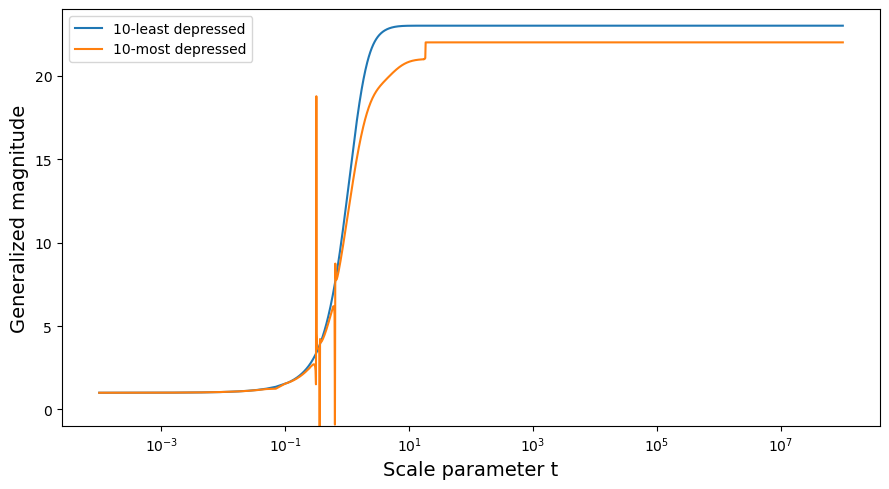

In [33]:
fig, ax = plt.subplots(figsize=[9, 5])

ax.plot(t_sorted, y_1, label="10-least depressed")
ax.plot(t_sorted, y_2, label="10-most depressed")

ax.set_xscale('log')
ax.set_ylim([-1, 24])
ax.set_xlabel("Scale parameter t", fontsize=14)
ax.set_ylabel("Generalized magnitude", fontsize=14)
ax.legend()

fig.tight_layout()
plt.show()